In [45]:
import os
import cv2
import kagglehub
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Input

In [46]:
path = kagglehub.dataset_download("sabahesaraki/breast-ultrasound-images-dataset")
dataset_path = f"{path}/Dataset_BUSI_with_GT"
print("Path to dataset:", dataset_path)

Path to dataset: /kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT


In [47]:
IMG_SIZE = 224 #Fixing the size of each image as 224x224

data = []
labels = []
classes = ["normal", "benign", "malignant"]

for label in classes:
    path = os.path.join(dataset_path, label)
    for img in tqdm(os.listdir(path)):
        img_path = os.path.join(path, img)
        image = cv2.imread(img_path)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0
        data.append(image)
        labels.append(label)

X = np.array(data)
y = np.array(labels)

print("Dataset shape:", X.shape)

100%|██████████| 421/421 [00:02<00:00, 166.19it/s]


Dataset shape: (1578, 224, 224, 3)


In [48]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(np.unique(y_encoded))
print("Classes:", le.classes_)

Classes: ['benign' 'malignant' 'normal']


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2, #80-20 split
    stratify=y_encoded,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1262, 224, 224, 3)
Test: (316, 224, 224, 3)


In [50]:
def build_cnn(): 
    """
    Function that builds a CNN model, which is the model used in both reference baseline results, as well as alongside after application of different techniques to handle class imbalance. 
    """
    
    inputs = Input(shape=(224,224,3))

    x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Flatten()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [51]:
def evaluate_model(model, X_test, y_test):
    """Standard evaluation function, for all models, including baseline and other models after handling class imbalance. Calculates specific required metrics, ensuring proper depiction of the affects of class imbalance, without focusing on accuracy alone."""
    
    preds = model.predict(X_test)
    preds = np.argmax(preds, axis=1)

    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, average='weighted')
    recall = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    report = classification_report(
        y_test,
        preds,
        target_names=classes,
        output_dict=True
    )

    return acc, precision, recall, f1, report

# **1. BASELINE MODEL**

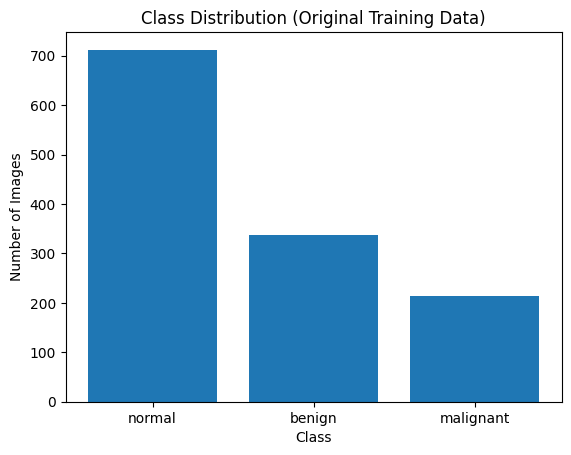

In [52]:
class_counts = np.bincount(y_train)

plt.figure()
plt.bar(classes, class_counts)
plt.title("Class Distribution (Original Training Data)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [53]:
baseline_model = build_cnn()

history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_report = evaluate_model(baseline_model, X_test, y_test)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 178ms/step - accuracy: 0.5488 - loss: 2.4594 - val_accuracy: 0.1811 - val_loss: 4.6971
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7335 - loss: 0.6863 - val_accuracy: 0.1811 - val_loss: 8.3435
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8187 - loss: 0.4611 - val_accuracy: 0.1811 - val_loss: 10.2992
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8627 - loss: 0.3568 - val_accuracy: 0.1811 - val_loss: 10.8934
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9036 - loss: 0.2489 - val_accuracy: 0.1811 - val_loss: 10.4061
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9184 - loss: 0.1982 - val_accuracy: 0.1811 - val_loss: 10.5474
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9273 - loss: 0.1934 - val_accuracy: 0.1811 - val_loss: 8.7018
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9521 - loss: 0.1352 - val_accuracy: 0.18

# **2. APPLYING CLASS WEIGHTS**

In [54]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights) #These are class weights computed using the inbuilt function, based on the representation of each class in the whole dataset

Class Weights: {0: np.float64(0.5908239700374532), 1: np.float64(1.248269040553907), 2: np.float64(1.9749608763693272)}


In [55]:
weighted_model = build_cnn()

history = weighted_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weights
)

weighted_acc, weighted_prec, weighted_rec, weighted_f1, weighted_report = evaluate_model(weighted_model, X_test, y_test)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - accuracy: 0.5116 - loss: 3.2378 - val_accuracy: 0.1811 - val_loss: 5.3005
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6911 - loss: 0.7290 - val_accuracy: 0.1811 - val_loss: 8.8411
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7715 - loss: 0.4851 - val_accuracy: 0.1811 - val_loss: 11.4997
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8362 - loss: 0.3389 - val_accuracy: 0.1811 - val_loss: 12.2514
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8715 - loss: 0.3020 - val_accuracy: 0.1811 - val_loss: 11.3796
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9051 - loss: 0.2073 - val_accuracy: 0.1811 - val_loss: 11.4944
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9336 - loss: 0.1921 - val_accuracy: 0.1811 - val_loss: 9.6141
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9560 - loss: 0.1315 - val_accuracy: 0.18

# **3. DATA AUGMENTATION**

In [56]:
#Application of basic data augmentation limited to rotation, horizontal and vertical translations, zooming, and lastly, flipping
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [57]:
X_aug = []
y_aug = []

class_counts = np.bincount(y_train)
max_count = np.max(class_counts)

for class_id in range(num_classes):
    imgs = X_train[y_train == class_id]
    needed = max_count - len(imgs)
    X_aug.extend(imgs)
    y_aug.extend([class_id]*len(imgs)) #Adding the augemented data to the original data

    if needed > 0:
        gen = augmentor.flow(imgs, batch_size=1)
        for _ in range(needed):
            img = next(gen)[0]
            X_aug.append(img)
            y_aug.append(class_id)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print("Original dataset:", X.shape)
print("Augmented dataset:", X_aug.shape)

Original dataset: (1578, 224, 224, 3)
Augmented dataset: (2136, 224, 224, 3)


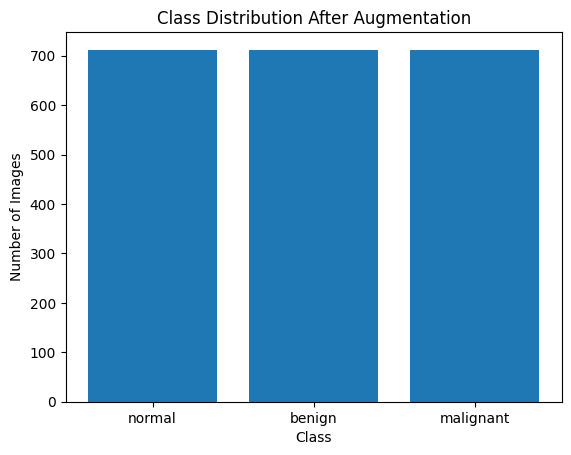

In [58]:
aug_counts = np.bincount(y_aug)

plt.figure()
plt.bar(classes, aug_counts)
plt.title("Class Distribution After Augmentation")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [59]:
aug_model = build_cnn()

history = aug_model.fit(
    X_aug, y_aug,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

aug_acc, aug_prec, aug_rec, aug_f1, aug_report = evaluate_model(aug_model, X_test, y_test)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - accuracy: 0.5863 - loss: 2.3087 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7241 - loss: 0.6895 - val_accuracy: 1.0000 - val_loss: 2.7491e-05
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8114 - loss: 0.4788 - val_accuracy: 1.0000 - val_loss: 3.9729e-06
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8381 - loss: 0.3745 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8680 - loss: 0.3532 - val_accuracy: 0.9673 - val_loss: 0.1066
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9058 - loss: 0.2552 - val_accuracy: 0.5935 - val_loss: 0.9557
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9045 - loss: 0.2546 - val_accuracy: 0.5607 - val_loss: 1.3643
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9377 - loss: 0.1805 - val_accuracy: 

# **4. SMOTE**

In [60]:
X_train_flat = X_train.reshape(len(X_train), -1)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_flat, y_train)
X_smote = X_smote.reshape(-1,224,224,3)

print("Original dataset:", X.shape)
print("SMOTE dataset:", X_smote.shape)

Original dataset: (1578, 224, 224, 3)
SMOTE dataset: (2136, 224, 224, 3)


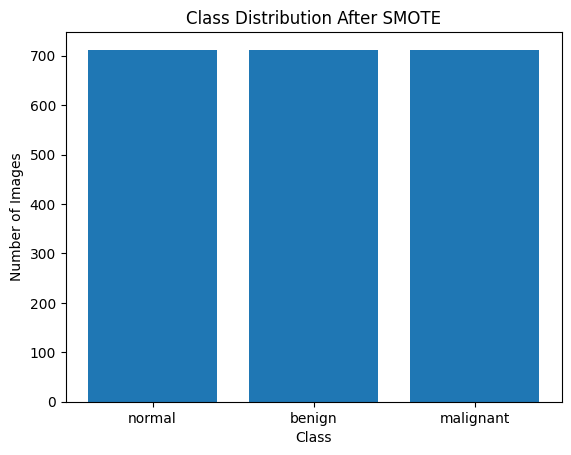

In [61]:
smote_counts = np.bincount(y_smote)

plt.figure()
plt.bar(classes, smote_counts)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [62]:
smote_model = build_cnn()

history = smote_model.fit(
    X_smote, y_smote,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

smote_acc, smote_prec, smote_rec, smote_f1, smote_report = evaluate_model(smote_model, X_test, y_test)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - accuracy: 0.5762 - loss: 2.3301 - val_accuracy: 1.0000 - val_loss: 0.0065
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8042 - loss: 0.5396 - val_accuracy: 1.0000 - val_loss: 0.0346
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8737 - loss: 0.3885 - val_accuracy: 1.0000 - val_loss: 0.0216
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9254 - loss: 0.2129 - val_accuracy: 1.0000 - val_loss: 0.0204
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9434 - loss: 0.1820 - val_accuracy: 0.6402 - val_loss: 0.8301
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9436 - loss: 0.1661 - val_accuracy: 0.0561 - val_loss: 3.0023
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9661 - loss: 0.1285 - val_accuracy: 0.0140 - val_loss: 2.2173
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9675 - loss: 0.0913 - val_accuracy: 0.2430 -

# **5. FOCAL LOSS**

In [63]:
def focal_loss(alpha=0.25, gamma=2.0):
    
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.one_hot(y_true, depth=num_classes)
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal = alpha * tf.pow((1 - p_t), gamma) * ce
        return tf.reduce_mean(focal)
        
    return loss

focal_model = build_cnn()

focal_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(alpha=0.25, gamma=2),
    metrics=['accuracy']
)

history = focal_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

focal_acc, focal_prec, focal_rec, focal_f1, focal_report = evaluate_model(focal_model, X_test, y_test)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 174ms/step - accuracy: 0.5446 - loss: 0.6595 - val_accuracy: 0.1811 - val_loss: 0.7183
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7265 - loss: 0.1207 - val_accuracy: 0.1811 - val_loss: 1.4429
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7677 - loss: 0.0745 - val_accuracy: 0.1811 - val_loss: 1.0860
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8083 - loss: 0.0504 - val_accuracy: 0.1811 - val_loss: 1.1976
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8256 - loss: 0.0438 - val_accuracy: 0.1811 - val_loss: 1.3777
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8852 - loss: 0.0271 - val_accuracy: 0.1890 - val_loss: 0.9245
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8963 - loss: 0.0246 - val_accuracy: 0.1890 - val_loss: 0.8373
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9059 - loss: 0.0229 - val_accuracy: 0.3386 -

# **RESULTS**

In [64]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Class Weights",
        "Augmentation",
        "SMOTE",
        "Focal Loss"
    ],
    "Accuracy": [
        baseline_acc,
        weighted_acc,
        aug_acc,
        smote_acc,
        focal_acc
    ],
    "Precision": [
        baseline_prec,
        weighted_prec,
        aug_prec,
        smote_prec,
        focal_prec
    ],
    "Recall": [
        baseline_rec,
        weighted_rec,
        aug_rec,
        smote_rec,
        focal_rec
    ],
    "F1 Score": [
        baseline_f1,
        weighted_f1,
        aug_f1,
        smote_f1,
        focal_f1
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.341772,0.495569,0.341772,0.315559
1,Class Weights,0.376582,0.451411,0.376582,0.368839
2,Augmentation,0.702532,0.756776,0.702532,0.707998
3,SMOTE,0.693038,0.734690,0.693038,0.702907
4,Focal Loss,0.563291,0.594408,0.563291,0.573633


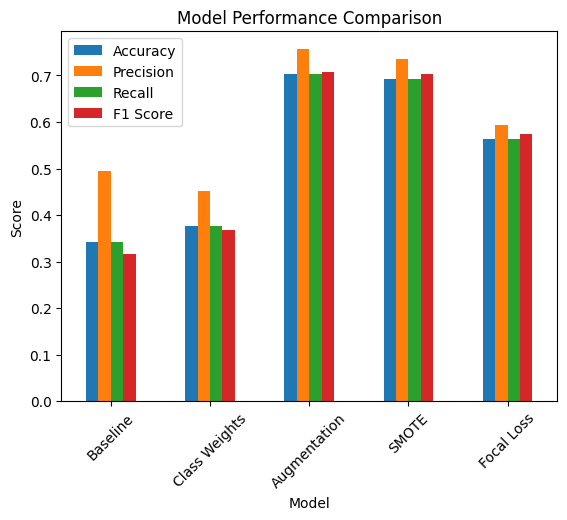

In [65]:
metrics = results.set_index("Model")

metrics.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [66]:
rows = []

models_reports = {
    "Baseline": (baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_report),
    "Class Weights": (weighted_acc, weighted_prec, weighted_rec, weighted_f1, weighted_report),
    "Augmentation": (aug_acc, aug_prec, aug_rec, aug_f1, aug_report),
    "SMOTE": (smote_acc, smote_prec, smote_rec, smote_f1, smote_report),
    "Focal Loss": (focal_acc, focal_prec, focal_rec, focal_f1, focal_report)
}

for model_name, (acc, prec, rec, f1, report) in models_reports.items():
    for cls in classes:
        rows.append({
            "Model": model_name,
            "Accuracy": acc,
            "Overall Precision": prec,
            "Overall Recall": rec,
            "Overall F1": f1,
            "Class": cls,
            "Class Precision": report[cls]["precision"],
            "Class Recall": report[cls]["recall"],
            "Class F1": report[cls]["f1-score"]
        })

final_results = pd.DataFrame(rows)
display(final_results)

,Model,Accuracy,Overall Precision,Overall Recall,Overall F1,Class,Class Precision,Class Recall,Class F1
0,Baseline,0.341772,0.495569,0.341772,0.315559,normal,0.539326,0.268156,0.358209
1,Baseline,0.341772,0.495569,0.341772,0.315559,benign,0.562500,0.107143,0.180000
2,Baseline,0.341772,0.495569,0.341772,0.315559,malignant,0.241706,0.962264,0.386364
3,Class Weights,0.376582,0.451411,0.376582,0.368839,normal,0.521739,0.268156,0.354244
4,Class Weights,0.376582,0.451411,0.376582,0.368839,benign,0.414286,0.345238,0.376623
5,Class Weights,0.376582,0.451411,0.376582,0.368839,malignant,0.272727,0.792453,0.405797
6,Augmentation,0.702532,0.756776,0.702532,0.707998,normal,0.873016,0.614525,0.721311
7,Augmentation,0.702532,0.756776,0.702532,0.707998,benign,0.526718,0.821429,0.641860
8,Augmentation,0.702532,0.756776,0.702532,0.707998,malignant,0.728814,0.811321,0.767857
9,SMOTE,0.693038,0.734690,0.693038,0.702907,normal,0.801282,0.698324,0.746269


In [67]:
malignant_recall = {
    "Baseline": baseline_report["malignant"]["recall"],
    "Class Weights": weighted_report["malignant"]["recall"],
    "Augmentation": aug_report["malignant"]["recall"],
    "SMOTE": smote_report["malignant"]["recall"],
    "Focal Loss": focal_report["malignant"]["recall"]
}

pd.DataFrame.from_dict(malignant_recall, orient="index", columns=["Malignant Recall"])

,Malignant Recall
Baseline,0.962264
Class Weights,0.792453
Augmentation,0.811321
SMOTE,0.641509
Focal Loss,0.641509


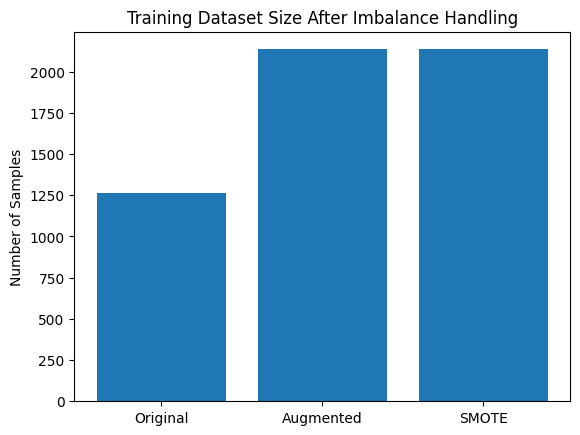

In [68]:
#Dataset size comparision

sizes = {
    "Original": len(X_train),
    "Augmented": len(X_aug),
    "SMOTE": len(X_smote)
}

plt.figure()
plt.bar(sizes.keys(), sizes.values())
plt.title("Training Dataset Size After Imbalance Handling")
plt.ylabel("Number of Samples")
plt.show()